## Patient 1 Analysis

In [1]:
import scipy.io
import mne

data_P1_pre_training = scipy.io.loadmat(r"C:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\stroke-rehab\P1_pre_training.mat")
data_P1_pre_test = scipy.io.loadmat(r"C:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\stroke-rehab\P1_pre_test.mat")

In [2]:
print(data_P1_pre_training.keys())
print(data_P1_pre_training["fs"])

trig_pre_training = data_P1_pre_training['trig']
y_pre_training = data_P1_pre_training['y']

print("trig shape:", trig_pre_training.shape)
print("y shape:", y_pre_training.shape)
print(data_P1_pre_training["__globals__"])

dict_keys(['__header__', '__version__', '__globals__', 'y', 'trig', 'fs'])
[[256]]
trig shape: (1, 271816)
y shape: (271816, 16)
[]


256


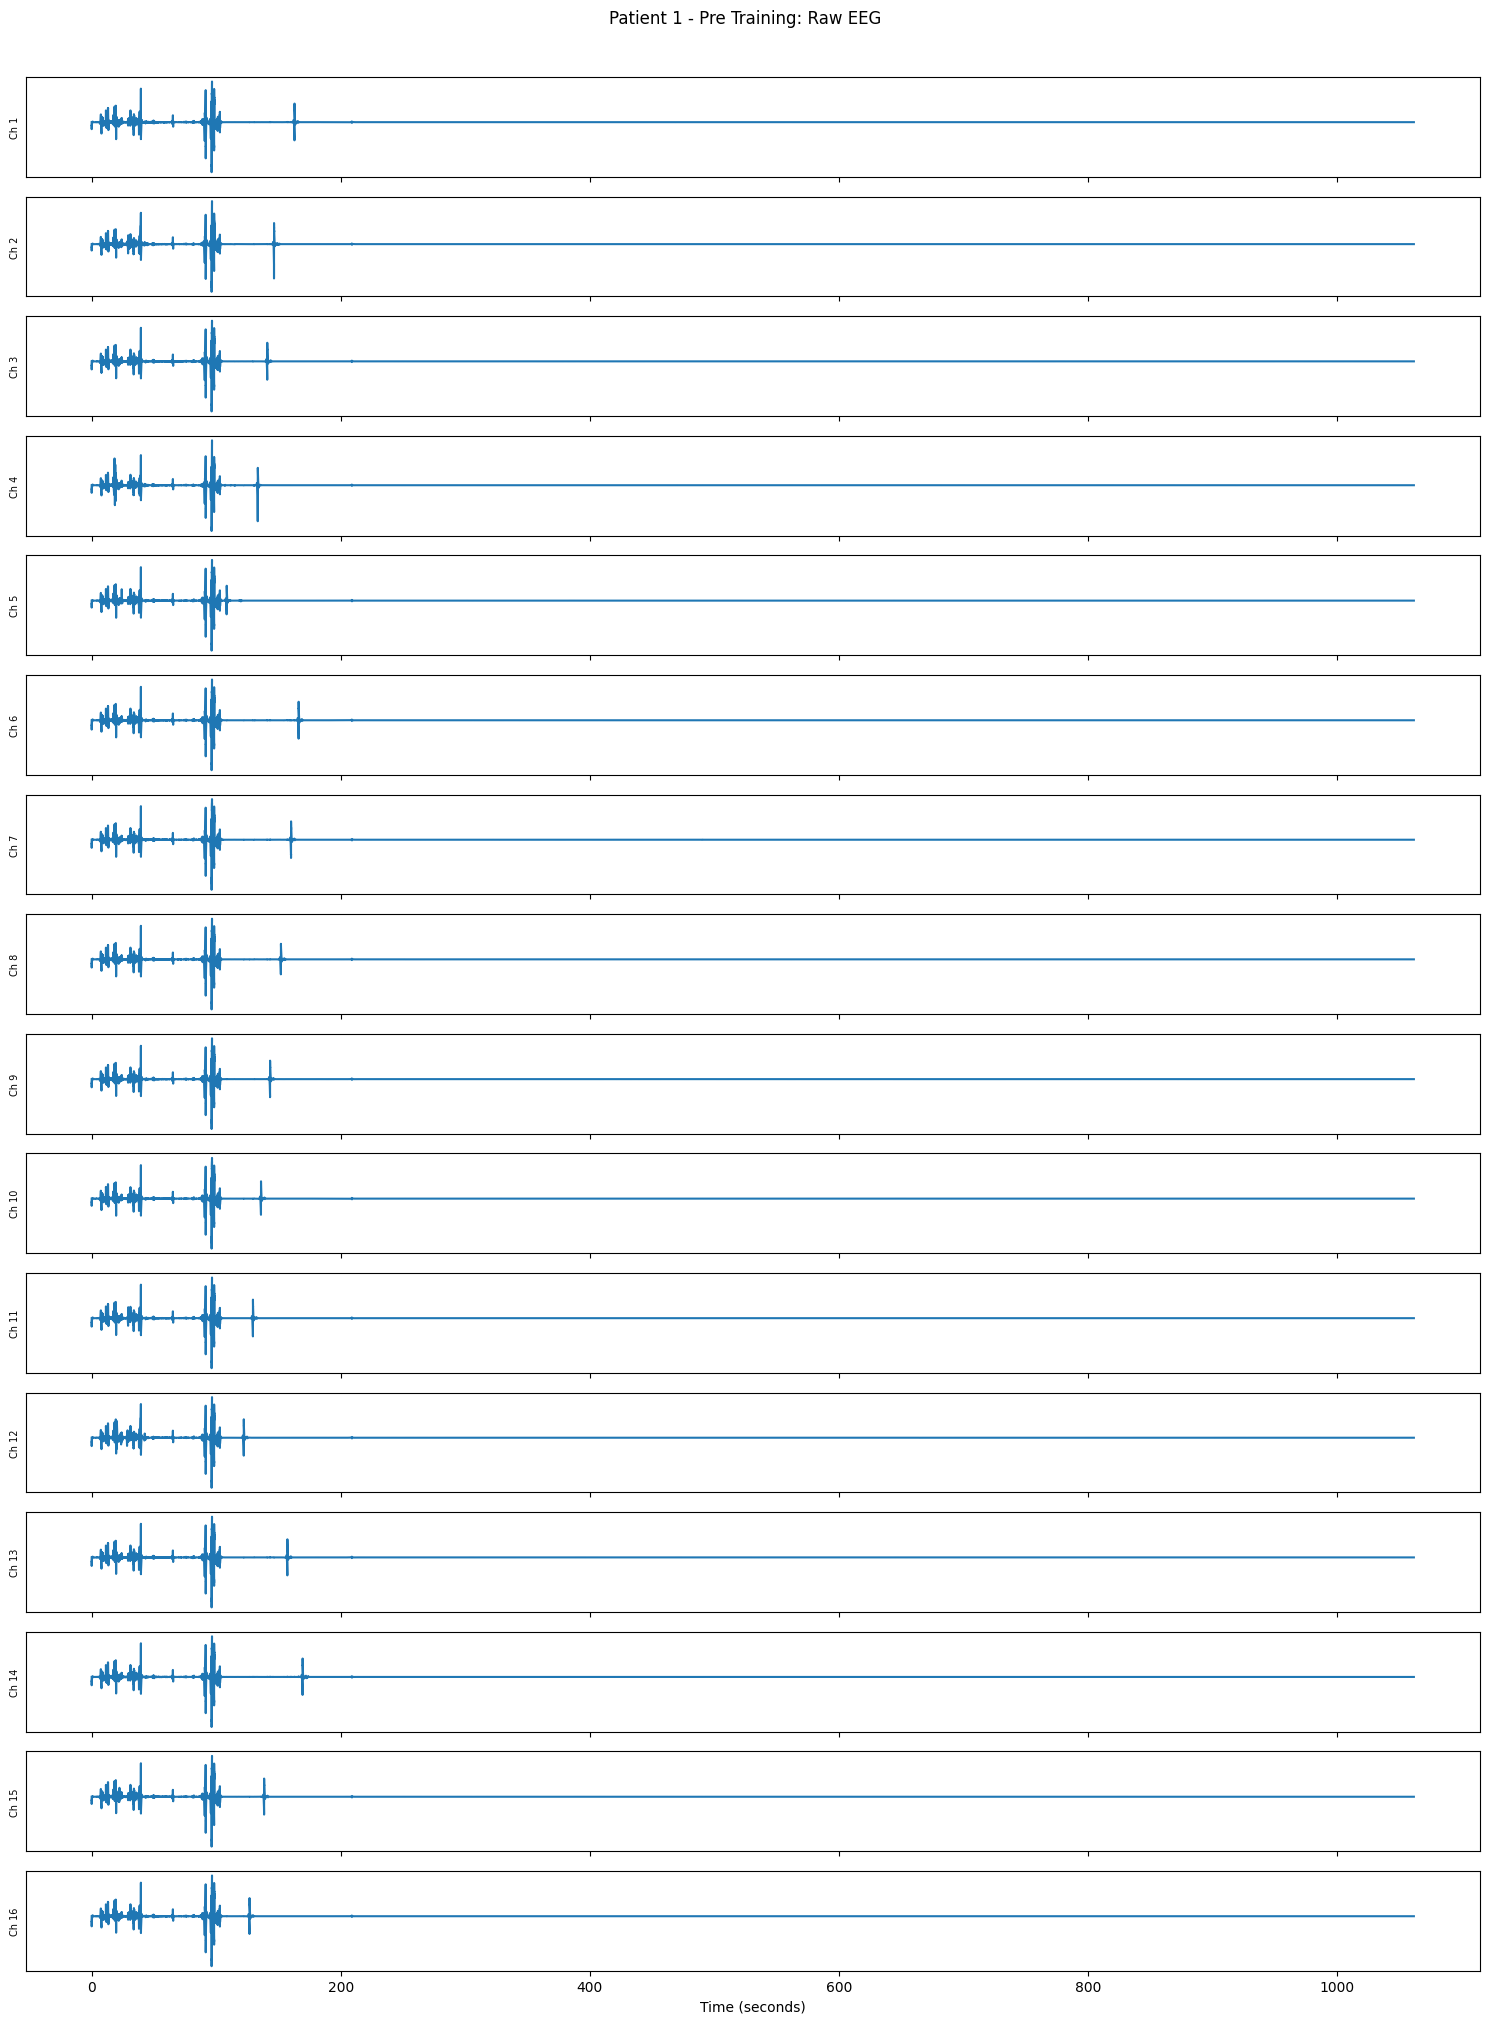

Plot saved!


In [3]:
import matplotlib.pyplot as plt
import numpy as np

fs = data_P1_pre_training["fs"][0][0] 
print(fs)
t = np.arange(y_pre_training.shape[0]) / fs

fig, axes = plt.subplots(16, 1, figsize=(15, 20), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(t, y_pre_training[:, i])
    ax.set_ylabel(f'Ch {i+1}', fontsize=7)
    ax.set_yticks([])

plt.xlabel('Time (seconds)')
plt.suptitle('Patient 1 - Pre Training: Raw EEG', y=1.01)
plt.tight_layout()
plt.savefig('P1_raw_eeg.png')
plt.show()
print("Plot saved!")



## Filtering

In [4]:
from scipy.signal import iirnotch, filtfilt
from scipy.signal import butter

def bandpass_filter(data, fs, lowcut, highcut, order):
    nyq = 0.5 * fs
    low = lowcut / nyq #the filter works in a normalized frequency range (0 to 1), where 1 corresponds to the Nyquist frequency
    high = highcut / nyq

    b,a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=0)

def notch_filter(data, fs, notch_freq, quality_factor=30):
    b, a = iirnotch(notch_freq, quality_factor, fs)
    return filtfilt(b, a, data, axis=0)

def trim_data(data, fs, start_time):
    start_sample = int(start_time * fs)
    return data[start_sample:, :]

def get_trigger_onsets(trig, fs):
    trig_1d = trig.flatten()
    onsets = np.where((trig_1d[1:] != 0) & (trig_1d[:-1] == 0))[0] + 1
    
    onset_times = onsets / fs
    return onset_times

In [5]:
trigger_events_time = get_trigger_onsets(trig_pre_training, fs)
print(trigger_events_time)

[ 257.1796875   266.84375     276.4375      286.03125     295.65625
  304.76171875  314.875       324.34375     334.1171875   343.78125
  353.375       362.9375      372.5234375   382.15625     391.75
  401.4375      410.9296875   420.58203125  430.15625     439.8125
  449.375       458.9375      468.5         478.15625     487.6875
  497.25        506.828125    516.453125    526.15625     535.78125
  545.40625     556.3125      565.82421875  575.53125     585.09375
  594.78125     604.40625     614.          623.6875      633.16015625
  674.53125     684.09375     693.65625     703.26171875  712.92578125
  723.125       732.71875     742.3125      751.90625     761.4375
  771.0625      780.625       790.28125     799.80859375  810.71875
  820.3125      829.85546875  839.53125     849.1875      858.75
  868.40625     877.875       887.53125     898.1875      907.78125
  917.375       926.8515625   936.53125     946.15625     955.6875
  965.2578125   974.96875     984.625       994.1875

In [6]:
y_pre_training = trim_data(y_pre_training, fs, start_time=255)

trig_trimmed = np.squeeze(trig_pre_training)[int(255*fs):]

print("Trimmed y shape:", y_pre_training.shape)
print("Trimmed trig shape:", trig_trimmed.shape)

y_pre_training_filtered = notch_filter(y_pre_training, fs, notch_freq=50)  # Remove 50 Hz powerline noise
y_pre_training_filtered = notch_filter(y_pre_training_filtered, fs, notch_freq=60)  # Remove 60 Hz powerline noise
y_pre_training_filtered = bandpass_filter(y_pre_training_filtered, fs, lowcut=1, highcut=40, order=4)  # Keep frequencies between 1 and 40 Hz

np.savez('P1_PRE_training_cleaned.npz', 
         data=y_pre_training_filtered, 
         trig=trig_trimmed) # Make sure triggers are trimmed too!

print("Data saved as P1_PRE_training_cleaned.npz")

Trimmed y shape: (206536, 16)
Trimmed trig shape: (206536,)
Data saved as P1_PRE_training_cleaned.npz


Total duration in array: 806.77734375 seconds
Data shape: (206536, 16)


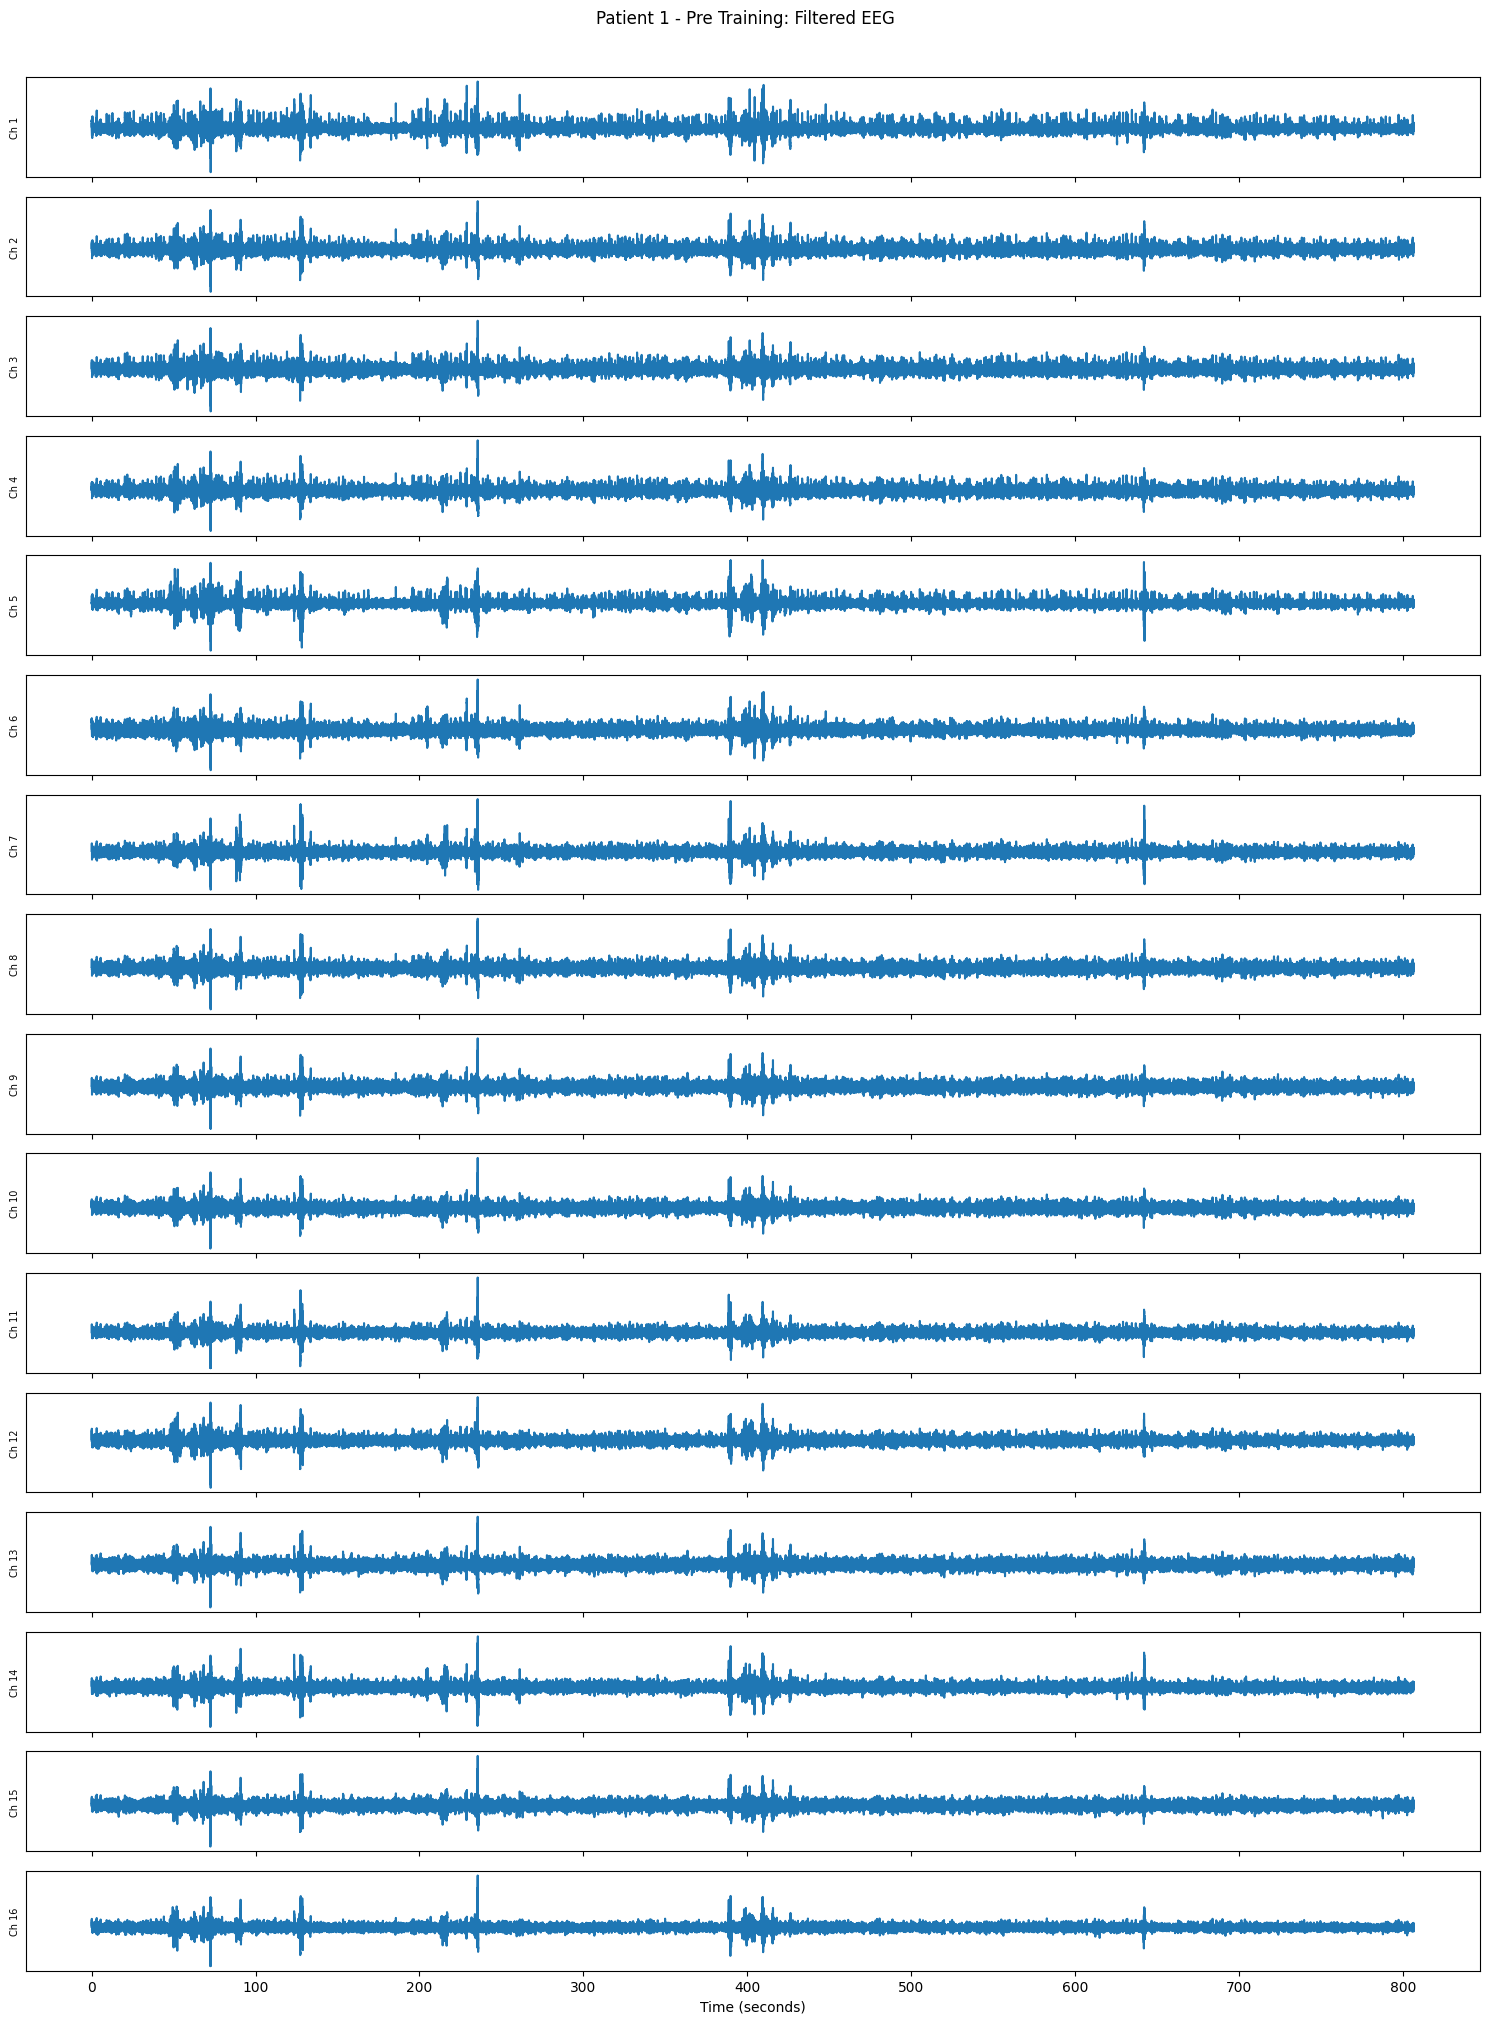

Plot saved!


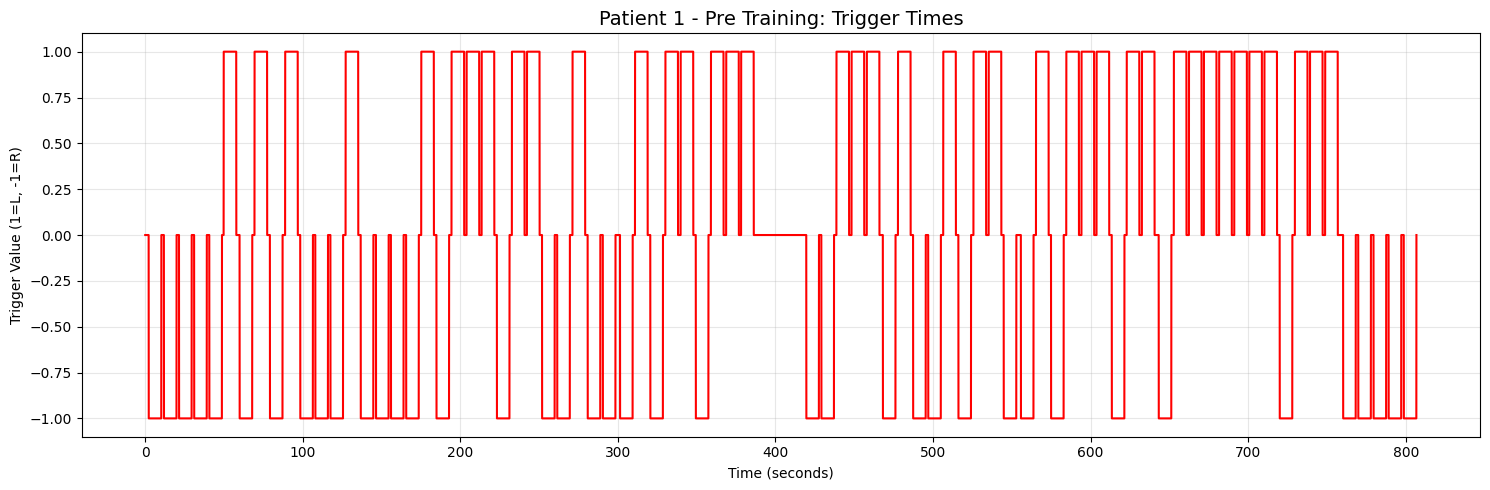

Trigger plot saved!


In [7]:
t_trimmed = np.arange(y_pre_training.shape[0]) / fs

print(f"Total duration in array: {t_trimmed[-1]} seconds")
print(f"Data shape: {y_pre_training_filtered.shape}")

fig, axes = plt.subplots(16, 1, figsize=(15, 20), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(t_trimmed, y_pre_training_filtered[:, i])
    ax.set_ylabel(f'Ch {i+1}', fontsize=7)
    ax.set_yticks([])

plt.xlabel('Time (seconds)')
plt.suptitle('Patient 1 - Pre Training: Filtered EEG', y=1.01)
plt.tight_layout()
plt.savefig('P1_filtered_eeg.png')
plt.show()
print("Plot saved!")



fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(t_trimmed, np.squeeze(trig_trimmed), color='red', lw=1.5)

ax.set_ylabel('Trigger Value (1=L, -1=R)', fontsize=10)
ax.set_xlabel('Time (seconds)', fontsize=10)
ax.set_title('Patient 1 - Pre Training: Trigger Times', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('P1_triggers.png')
plt.show()

print("Trigger plot saved!")

In [8]:
import numpy as np

def epoch_data(data, trig, fs, time_after, period_of_interest):
    samples_after = int(time_after * fs)
    samples_interest = int(period_of_interest * fs)

    trigger_events_time = get_trigger_onsets(trig, fs)

    right_hand_epochs = []
    left_hand_epochs = []

    trig_flat = trig.flatten()

    for onset_time in trigger_events_time:
        idx_onset = int(round(onset_time * fs))

        window = trig_flat[max(0, idx_onset-2):idx_onset+3]
        label = int(np.sign(np.sum(window)))

        start_idx = idx_onset + samples_after
        end_idx = start_idx + samples_interest

        if end_idx <= data.shape[0]:
            epoch = data[start_idx:end_idx, :]

            if label == -1:
                right_hand_epochs.append(epoch)
            elif label == 1:
                left_hand_epochs.append(epoch)

    return np.array(right_hand_epochs), np.array(left_hand_epochs)


In [9]:
right_hand_epochs_p1_pre_training, left_hand_epochs_p1_pre_training = epoch_data(y_pre_training_filtered, trig_trimmed, fs, time_after=2.0, period_of_interest=6.0)
print(right_hand_epochs_p1_pre_training.shape)

(40, 1536, 16)


In [10]:
CHANNEL_NAMES = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','Pz']

info = mne.create_info(ch_names=CHANNEL_NAMES, sfreq=fs, ch_types='eeg')

montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

<Info | 8 non-empty values
 bads: []
 ch_names: FC3, FCz, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, CP1, CPz, CP2, ...
 chs: 16 EEG
 custom_ref_applied: False
 dig: 19 items (3 Cardinal, 16 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 16
 projs: []
 sfreq: 256.0 Hz
>

In [11]:
from preprocessing_functions import *
from autoreject import AutoReject
import json

right_hand_epochs_p1_pre_training = autoreject_epochs(right_hand_epochs_p1_pre_training, info=info)
left_hand_epochs_p1_pre_training = autoreject_epochs(left_hand_epochs_p1_pre_training, info=info)

Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated


c:\Users\rodri\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running autoreject on ch_type=eeg


100%|██████████| Creating augmented epochs : 16/16 [00:00<00:00,   84.65it/s]
100%|██████████| Computing thresholds ... : 16/16 [00:11<00:00,    1.40it/s]














100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  146.95it/s]



















100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  118.15it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    6.90it/s]















100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  134.09it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    8.33it/s]



















100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  116.36it/s]






















100%|██████████| Fold : 10/10 [00:00<00:00,   52.58it/s]
100%|██████████| n_interp : 3/3 [00:03<00:00,    1.33s/it]






Estimated consensus=0.50 and n_interpolate=4


...

40 matching events found
No baseline correction applied
0 projection items activated
Running autoreject on ch_type=eeg


100%|██████████| Creating augmented epochs : 16/16 [00:00<00:00,   85.74it/s]
100%|██████████| Computing thresholds ... : 16/16 [00:10<00:00,    1.47it/s]














100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  154.20it/s]

















100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  125.07it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    7.09it/s]















100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  149.24it/s]






















100%|██████████| Fold : 10/10 [00:01<00:00,    8.72it/s]

c:\Users\rodri\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\rodri\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)















100%|██████████| Repairing e





Estimated consensus=0.90 and n_interpolate=4





















100%|██████████| Repairing epochs : 40/40 [00:00<00:00,  113.21it/s]

Dropped 4 epochs: 0, 1, 2, 8
AutoReject: 40 → 36 epochs


In [12]:

import json
import numpy as np

data_to_save = {
    "right_hand_epochs": right_hand_epochs_p1_pre_training.tolist(),
    "left_hand_epochs": left_hand_epochs_p1_pre_training.tolist(),
    "labels": {
        "right": -1,
        "left": 1
    },
    "shape_info": {
        "format": "(epochs, samples, channels)",
        "right_shape": right_hand_epochs_p1_pre_training.shape,
        "left_shape": left_hand_epochs_p1_pre_training.shape
    }
}

with open("P1_epochs_clean.json", "w") as f:
    json.dump(data_to_save, f)

print("Saved successfully!")

Saved successfully!


In [13]:
from scipy.signal import welch

def get_band_power(epochs, fs, low=8, high=30):
    """
    epochs: (trials, samples, channels)
    returns: (channels,)
    """

    band_power_all = []

    for epoch in epochs:
        ch_power = []

        for ch in range(epoch.shape[1]):

            f, Pxx = welch(epoch[:, ch], fs=fs, nperseg=fs*2)

            idx = (f >= low) & (f <= high)
            band_power = np.trapz(Pxx[idx], f[idx])

            ch_power.append(band_power)

        band_power_all.append(ch_power)

    return np.mean(band_power_all, axis=0)

In [14]:
mu_left_pre_training = get_band_power(left_hand_epochs_p1_pre_training, fs=256, low=8, high=12)
mu_right_pre_training = get_band_power(right_hand_epochs_p1_pre_training, fs=256, low=8, high=12)

beta_left_pre_training = get_band_power(left_hand_epochs_p1_pre_training, fs=256, low=13, high=30)
beta_right_pre_training = get_band_power(right_hand_epochs_p1_pre_training, fs=256, low=13, high=30)

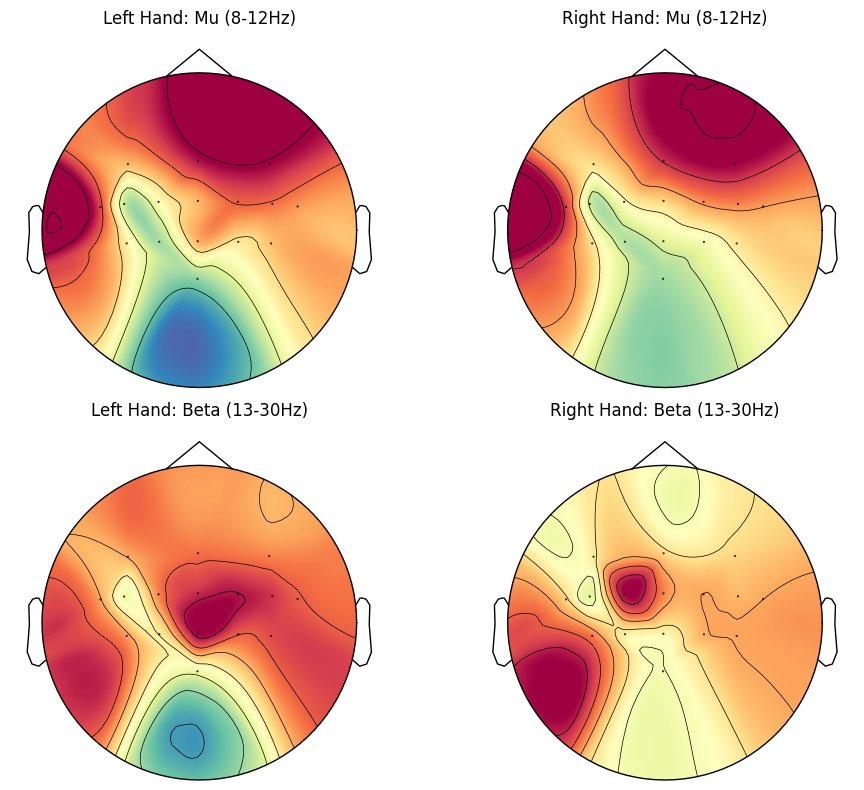

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Row 0: Mu Band
mne.viz.plot_topomap(mu_left_pre_training, info, axes=axes[0, 0], show=False, cmap='Spectral_r')
axes[0, 0].set_title("Left Hand: Mu (8-12Hz)")

mne.viz.plot_topomap(mu_right_pre_training, info, axes=axes[0, 1], show=False, cmap='Spectral_r')
axes[0, 1].set_title("Right Hand: Mu (8-12Hz)")

# Row 1: Beta Band
mne.viz.plot_topomap(beta_left_pre_training, info, axes=axes[1, 0], show=False, cmap='Spectral_r')
axes[1, 0].set_title("Left Hand: Beta (13-30Hz)")

mne.viz.plot_topomap(beta_right_pre_training, info, axes=axes[1, 1], show=False, cmap='Spectral_r')
axes[1, 1].set_title("Right Hand: Beta (13-30Hz)")

plt.tight_layout()
plt.show()

In [ ]:
ref_right, ref_left = epoch_data(
    y_pre_training_filtered,
    trig_trimmed,
    fs,
    time_after=-1.0,
    period_of_interest=1.0
)

def calculate_erd_ers(active_epochs, ref_epochs, fs, low, high):
    A = get_band_power(active_epochs, fs, low, high)
    R = get_band_power(ref_epochs, fs, low, high)

    return 10 * np.log10(A / R)

mu_erd_left = calculate_erd_ers(left_hand_epochs_p1_pre_training, ref_left, fs, 8, 12)
mu_erd_right = calculate_erd_ers(right_hand_epochs_p1_pre_training, ref_right, fs, 8, 12)

beta_erd_left = calculate_erd_ers(left_hand_epochs_p1_pre_training, ref_left, fs, 13, 30)
beta_erd_right = calculate_erd_ers(right_hand_epochs_p1_pre_training, ref_right, fs, 13, 30)


C:\Users\rodri\AppData\Local\Temp\ipykernel_28360\427921302.py:16: UserWarning: nperseg=512 is greater than signal length max(len(x), len(y)) = 256, using nperseg = 256
  f, Pxx = welch(epoch[:, ch], fs=fs, nperseg=fs*2)


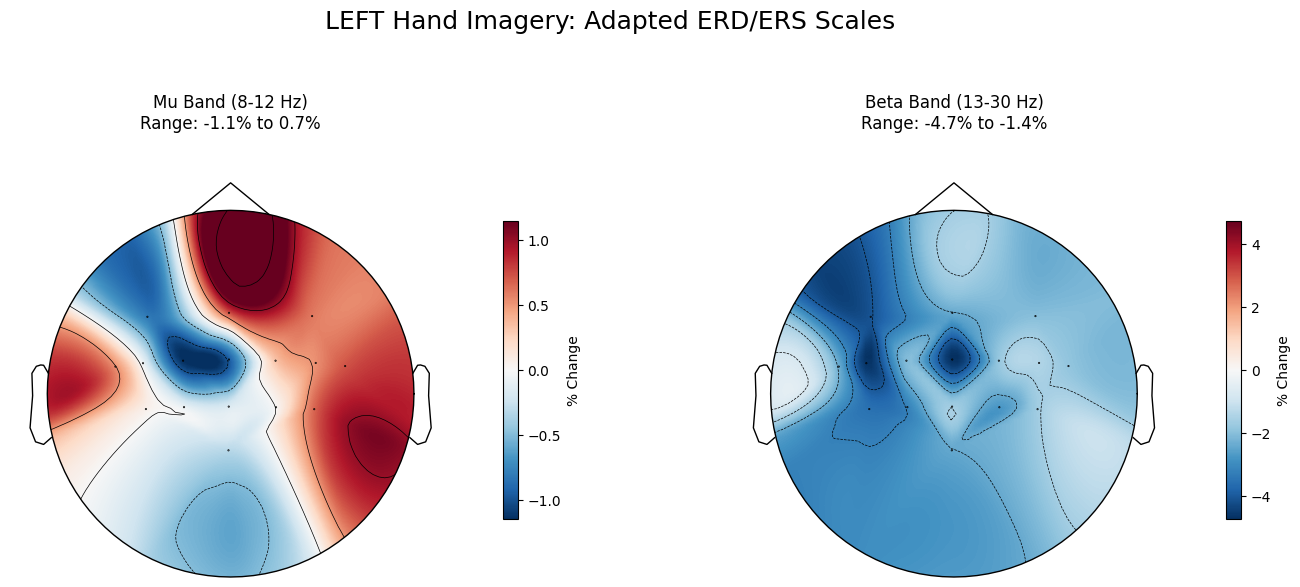

In [17]:
fig_left, axes_left = plt.subplots(1, 2, figsize=(16, 7)) # Increased width slightly

map_params_left = dict(pos=info, cmap='RdBu_r', show=False)

# 1. Mu Band
im_mu_l, _ = mne.viz.plot_topomap(mu_erd_left, axes=axes_left[0], **map_params_left)
# Added 'pad=25' to push title up
axes_left[0].set_title(f"Mu Band (8-12 Hz)\nRange: {mu_erd_left.min():.1f}% to {mu_erd_left.max():.1f}%", pad=25)
# Added 'fraction' and 'pad' to the colorbar to prevent overlapping
fig_left.colorbar(im_mu_l, ax=axes_left[0], orientation='vertical', shrink=0.6, fraction=0.046, pad=0.1, label='% Change')

# 2. Beta Band
im_beta_l, _ = mne.viz.plot_topomap(beta_erd_left, axes=axes_left[1], **map_params_left)
axes_left[1].set_title(f"Beta Band (13-30 Hz)\nRange: {beta_erd_left.min():.1f}% to {beta_erd_left.max():.1f}%", pad=25)
fig_left.colorbar(im_beta_l, ax=axes_left[1], orientation='vertical', shrink=0.6, fraction=0.046, pad=0.1, label='% Change')

# Use subplots_adjust to force room at the top for the suptitle
plt.subplots_adjust(top=0.82, wspace=0.4) 
fig_left.suptitle("LEFT Hand Imagery: Adapted ERD/ERS Scales", fontsize=18, y=0.98)

plt.show()

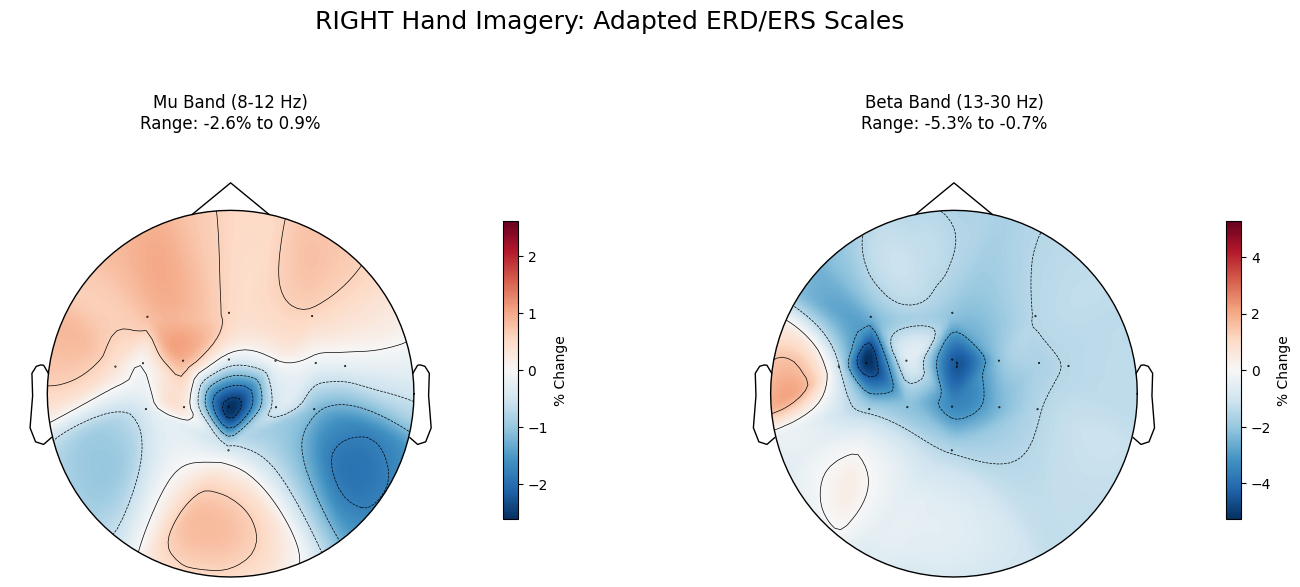

In [18]:
fig_right, axes_right = plt.subplots(1, 2, figsize=(16, 7))

map_params_right = dict(pos=info, cmap='RdBu_r', show=False)

# 1. Mu Band
im_mu_r, _ = mne.viz.plot_topomap(mu_erd_right, axes=axes_right[0], **map_params_right)
axes_right[0].set_title(f"Mu Band (8-12 Hz)\nRange: {mu_erd_right.min():.1f}% to {mu_erd_right.max():.1f}%", pad=25)
fig_right.colorbar(im_mu_r, ax=axes_right[0], orientation='vertical', shrink=0.6, fraction=0.046, pad=0.1, label='% Change')

# 2. Beta Band
im_beta_r, _ = mne.viz.plot_topomap(beta_erd_right, axes=axes_right[1], **map_params_right)
axes_right[1].set_title(f"Beta Band (13-30 Hz)\nRange: {beta_erd_right.min():.1f}% to {beta_erd_right.max():.1f}%", pad=25)
fig_right.colorbar(im_beta_r, ax=axes_right[1], orientation='vertical', shrink=0.6, fraction=0.046, pad=0.1, label='% Change')

plt.subplots_adjust(top=0.82, wspace=0.4)
fig_right.suptitle("RIGHT Hand Imagery: Adapted ERD/ERS Scales", fontsize=18, y=0.98)

plt.show()

Original EEG Shape: (197343, 16)
Original Trigger Shape: (197343,)


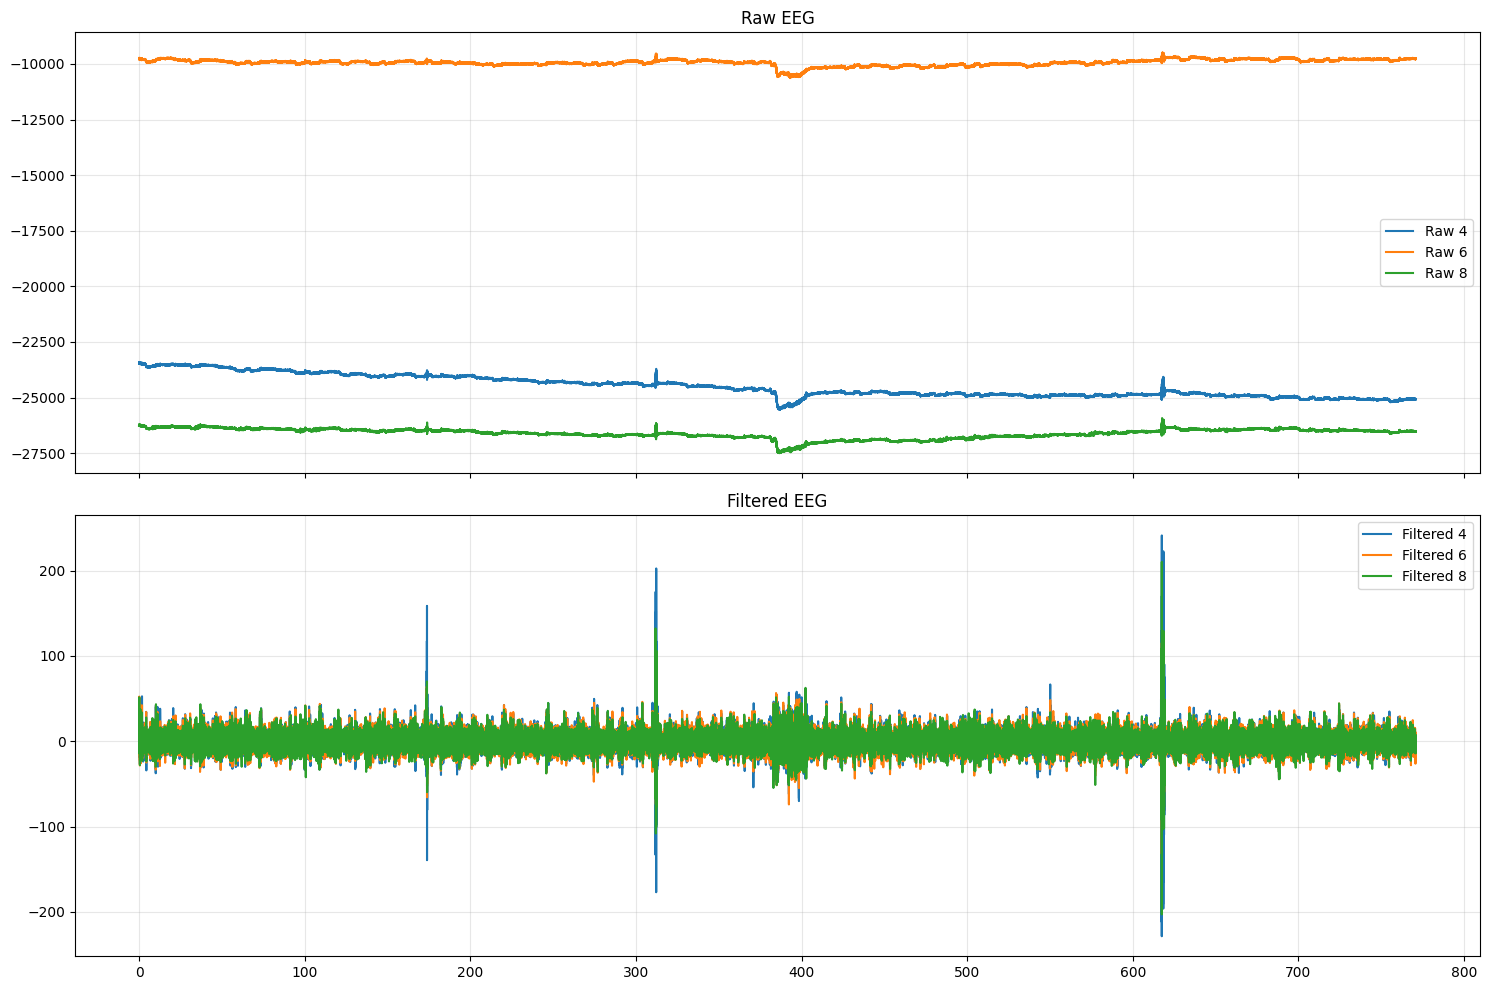

Right Hand Epochs: (40, 1536, 16)
Left Hand Epochs: (40, 1536, 16)
[-1  0  1]
80


In [19]:
import numpy as np
import scipy.io
import mne
import matplotlib.pyplot as plt

# --- 1. LOAD DATA ---
path_post_training = r"C:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\stroke-rehab\P1_post_training.mat"
data_P1_post_training = scipy.io.loadmat(path_post_training)

y_raw = data_P1_post_training['y']
trig_raw = data_P1_post_training['trig'].flatten() 
fs = data_P1_post_training["fs"][0][0]

print(f"Original EEG Shape: {y_raw.shape}")
print(f"Original Trigger Shape: {trig_raw.shape}")

# 1. Create a time vector based on the raw EEG length
t_raw = np.arange(y_raw.shape[0]) / fs

# 1. Apply the filters sequentially to the raw data
# We use y_raw directly to keep the original size
y_filt_50 = notch_filter(y_raw, fs, notch_freq=50)
y_filt_60 = notch_filter(y_filt_50, fs, notch_freq=60)
y_post_training_filtered = bandpass_filter(y_filt_60, fs, lowcut=1, highcut=40, order=4)  # Keep frequencies between 1 and 40 Hz

channels_to_view = [4, 6, 8]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for ch in channels_to_view:
    ax1.plot(t_raw, y_raw[:, ch], label=f"Raw {ch}")

ax1.set_title("Raw EEG")
ax1.legend()
ax1.grid(True, alpha=0.3)

for ch in channels_to_view:
    ax2.plot(t_raw, y_post_training_filtered[:, ch], label=f"Filtered {ch}")

ax2.set_title("Filtered EEG")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

trig_post_final = trig_raw  # IMPORTANT: 1D ONLY

# --- 4. EPOCHING ---
# Using the original, un-synced data and triggers
right_hand_epochs_post, left_hand_epochs_post = epoch_data(
    y_post_training_filtered, 
    trig_post_final, 
    fs, 
    time_after=2.0, 
    period_of_interest=6.0
)

print(f"Right Hand Epochs: {right_hand_epochs_post.shape}")
print(f"Left Hand Epochs: {left_hand_epochs_post.shape}")

# --- 5. MNE SETUP ---
CHANNEL_NAMES = ['FC3','FCz','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','Pz']
info = mne.create_info(ch_names=CHANNEL_NAMES, sfreq=fs, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

print(np.unique(trig_raw))
print(len(get_trigger_onsets(trig_post_final, fs)))

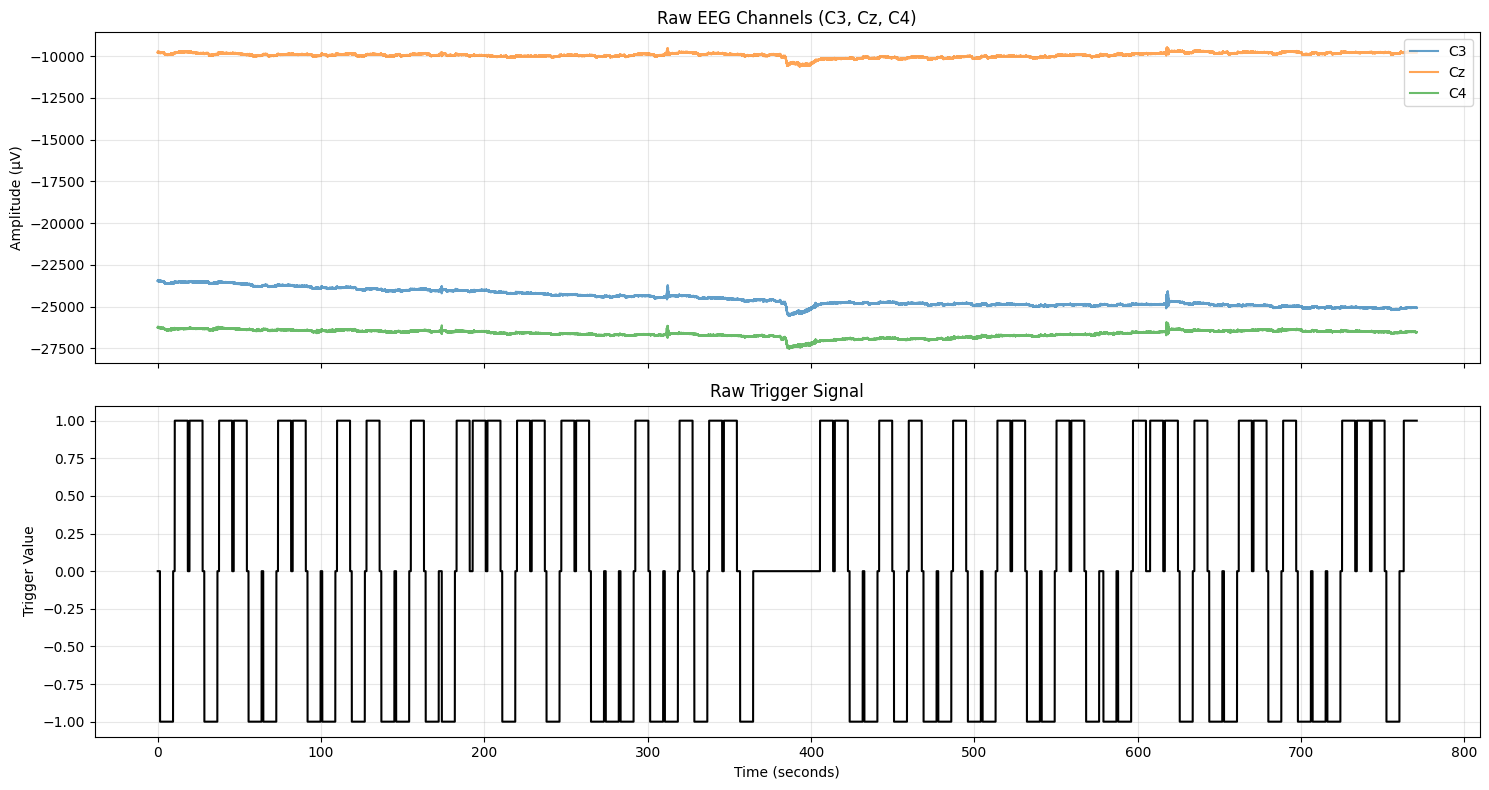

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Time vector
t_raw = np.arange(y_raw.shape[0]) / fs

# Channels to inspect (C3, Cz, C4)
channels_to_plot = [4, 6, 8]

fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# --- EEG ---
for ch in channels_to_plot:
    ax[0].plot(t_raw, y_raw[:, ch], label=CHANNEL_NAMES[ch], alpha=0.7)

ax[0].set_title("Raw EEG Channels (C3, Cz, C4)")
ax[0].set_ylabel("Amplitude (µV)")
ax[0].legend(loc='upper right')
ax[0].grid(True, alpha=0.3)

# --- TRIGGER (IMPORTANT FIX) ---
ax[1].plot(t_raw, trig_raw.flatten(), color='black', label='Trigger Signal')

ax[1].set_title("Raw Trigger Signal")
ax[1].set_ylabel("Trigger Value")
ax[1].set_xlabel("Time (seconds)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

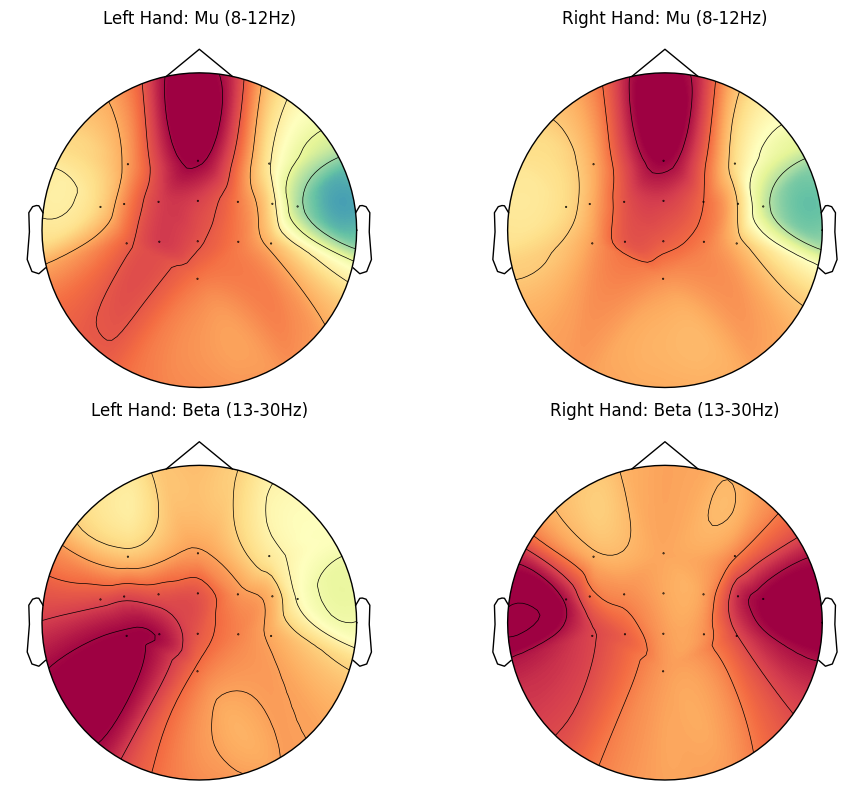

In [21]:
mu_left_post_training = get_band_power(left_hand_epochs_post, fs=256, low=8, high=12)
mu_right_post_training = get_band_power(right_hand_epochs_post, fs=256, low=8, high=12)

beta_left_post_training = get_band_power(left_hand_epochs_post, fs=256, low=13, high=30)
beta_right_post_training = get_band_power(right_hand_epochs_post, fs=256, low=13, high=30)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Row 0: Mu Band
mne.viz.plot_topomap(mu_left_post_training, info, axes=axes[0, 0], show=False, cmap='Spectral_r')
axes[0, 0].set_title("Left Hand: Mu (8-12Hz)")

mne.viz.plot_topomap(mu_right_post_training, info, axes=axes[0, 1], show=False, cmap='Spectral_r')
axes[0, 1].set_title("Right Hand: Mu (8-12Hz)")

# Row 1: Beta Band
mne.viz.plot_topomap(beta_left_post_training, info, axes=axes[1, 0], show=False, cmap='Spectral_r')
axes[1, 0].set_title("Left Hand: Beta (13-30Hz)")

mne.viz.plot_topomap(beta_right_post_training, info, axes=axes[1, 1], show=False, cmap='Spectral_r')
axes[1, 1].set_title("Right Hand: Beta (13-30Hz)")

plt.tight_layout()
plt.show()

C:\Users\rodri\AppData\Local\Temp\ipykernel_28360\427921302.py:16: UserWarning: nperseg=512 is greater than signal length max(len(x), len(y)) = 256, using nperseg = 256
  f, Pxx = welch(epoch[:, ch], fs=fs, nperseg=fs*2)


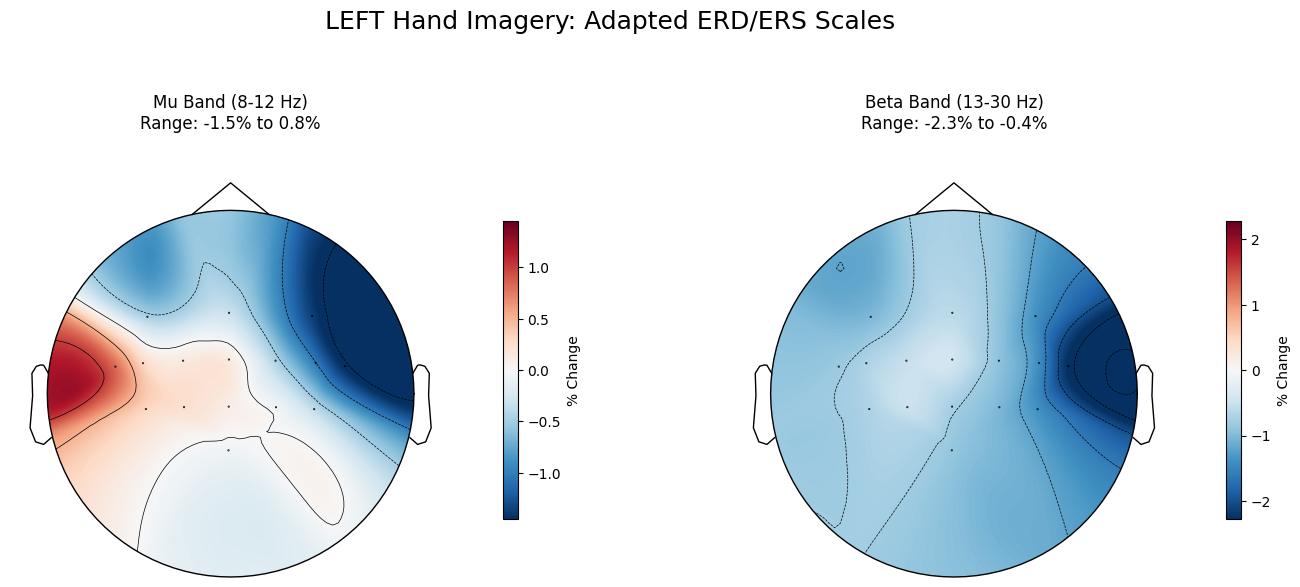

In [22]:
ref_right_post, ref_left_post = epoch_data(
    y_post_training_filtered,
    trig_post_final,
    fs,
    time_after=-1.0,
    period_of_interest=1.0
)

def calculate_erd_ers(active_epochs, ref_epochs, fs, low, high):
    A = get_band_power(active_epochs, fs, low, high)
    R = get_band_power(ref_epochs, fs, low, high)

    return 10 * np.log10(A / R)

mu_erd_left_post = calculate_erd_ers(left_hand_epochs_post, ref_left_post, fs, 8, 12)
mu_erd_right_post = calculate_erd_ers(right_hand_epochs_post, ref_right_post, fs, 8, 12)

beta_erd_left_post = calculate_erd_ers(left_hand_epochs_post, ref_left_post, fs, 13, 30)
beta_erd_right_post = calculate_erd_ers(right_hand_epochs_post, ref_right_post, fs, 13, 30)



fig_left, axes_left = plt.subplots(1, 2, figsize=(16, 7)) # Increased width slightly

map_params_left = dict(pos=info, cmap='RdBu_r', show=False)

# 1. Mu Band
im_mu_l, _ = mne.viz.plot_topomap(mu_erd_left_post, axes=axes_left[0], **map_params_left)
# Added 'pad=25' to push title up
axes_left[0].set_title(f"Mu Band (8-12 Hz)\nRange: {mu_erd_left_post.min():.1f}% to {mu_erd_left_post.max():.1f}%", pad=25)
# Added 'fraction' and 'pad' to the colorbar to prevent overlapping
fig_left.colorbar(im_mu_l, ax=axes_left[0], orientation='vertical', shrink=0.6, fraction=0.046, pad=0.1, label='% Change')

# 2. Beta Band
im_beta_l, _ = mne.viz.plot_topomap(beta_erd_left_post, axes=axes_left[1], **map_params_left)
axes_left[1].set_title(f"Beta Band (13-30 Hz)\nRange: {beta_erd_left_post.min():.1f}% to {beta_erd_left_post.max():.1f}%", pad=25)
fig_left.colorbar(im_beta_l, ax=axes_left[1], orientation='vertical', shrink=0.6, fraction=0.046, pad=0.1, label='% Change')

# Use subplots_adjust to force room at the top for the suptitle
plt.subplots_adjust(top=0.82, wspace=0.4) 
fig_left.suptitle("LEFT Hand Imagery: Adapted ERD/ERS Scales", fontsize=18, y=0.98)

plt.show()

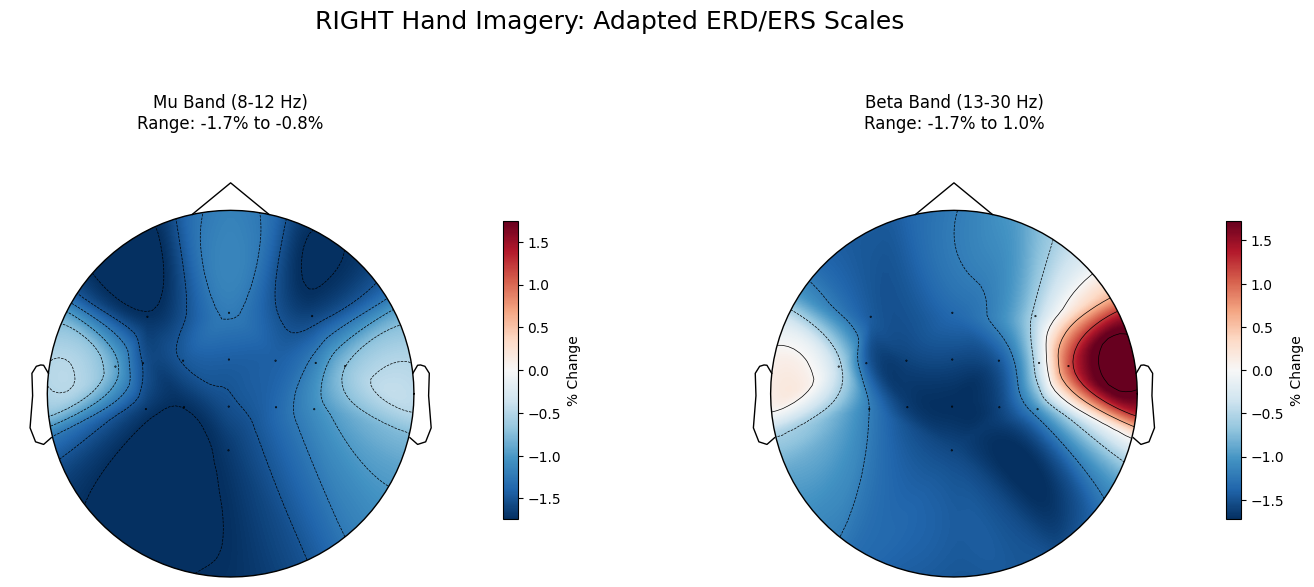

In [23]:
fig_right, axes_right = plt.subplots(1, 2, figsize=(16, 7))

map_params_right = dict(pos=info, cmap='RdBu_r', show=False)

# 1. Mu Band
im_mu_r, _ = mne.viz.plot_topomap(mu_erd_right_post, axes=axes_right[0], **map_params_right)
axes_right[0].set_title(f"Mu Band (8-12 Hz)\nRange: {mu_erd_right_post.min():.1f}% to {mu_erd_right_post.max():.1f}%", pad=25)
fig_right.colorbar(im_mu_r, ax=axes_right[0], orientation='vertical', shrink=0.6, fraction=0.046, pad=0.1, label='% Change')

# 2. Beta Band
im_beta_r, _ = mne.viz.plot_topomap(beta_erd_right_post, axes=axes_right[1], **map_params_right)
axes_right[1].set_title(f"Beta Band (13-30 Hz)\nRange: {beta_erd_right_post.min():.1f}% to {beta_erd_right_post.max():.1f}%", pad=25)
fig_right.colorbar(im_beta_r, ax=axes_right[1], orientation='vertical', shrink=0.6, fraction=0.046, pad=0.1, label='% Change')

plt.subplots_adjust(top=0.82, wspace=0.4)
fig_right.suptitle("RIGHT Hand Imagery: Adapted ERD/ERS Scales", fontsize=18, y=0.98)

plt.show()